In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Install OSMnx — takes ~60s on Colab, skip if already installed
import importlib, subprocess, sys

if importlib.util.find_spec("osmnx") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install",
                           "osmnx", "-q", "--disable-pip-version-check"])
    print("osmnx installed.")
else:
    print("osmnx already present.")

osmnx installed.


In [3]:
import os
import time
import warnings
import pandas as pd
import numpy as np
import osmnx as ox
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
warnings.filterwarnings("ignore")

ox.settings.log_console   = False
ox.settings.use_cache     = True        # caches OSM tiles locally
ox.settings.timeout       = 60          # per-request timeout (seconds)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 130, "font.size": 11})

# ── Paths (update to your Drive location) ────────────────────────────────────
BASE     = "/content/drive/MyDrive/gridlock_flipkart"
SUM_IN   = f"{BASE}/cluster_summary_updated.csv"
CKPT     = f"{BASE}/osm_checkpoint.csv"
OUT_NET  = f"{BASE}/road_network_exposure.csv"
SUM_OUT  = f"{BASE}/cluster_summary_updated.csv"

cluster_summary = pd.read_csv(SUM_IN)
print(f"Clusters to query: {len(cluster_summary)}")
cluster_summary[["cluster_id", "centroid_lat", "centroid_lon", "top_station"]].head()

Clusters to query: 30


,cluster_id,centroid_lat,centroid_lon,top_station
0,29,12.977098,77.576941,Upparpet
1,7,12.915963,77.625859,HSR Layout
2,25,12.964669,77.578713,City Market
3,11,13.000357,77.570468,Malleshwaram
4,27,12.971175,77.577458,Upparpet


## 1. Road hierarchy and `road_importance` weights

OSM `highway` tags are mapped to a 0–1 importance score based on how much
traffic flow a parked vehicle disrupts on that road type.

| OSM tag | Description | Score |
|---|---|---|
| motorway / trunk | Expressway-grade | 1.0 |
| primary | Major arterial | 0.9 |
| secondary | District connector | 0.7 |
| tertiary | Neighbourhood link | 0.5 |
| residential / living_street | Local street | 0.3 |
| service / unclassified / other | Access road | 0.1 |

`road_importance` per cluster = **weighted mean** of all road segments within
200 m of the centroid, weighted by segment length (longer segments count more).


In [4]:
HIGHWAY_SCORES = {
    "motorway":       1.0,
    "motorway_link":  1.0,
    "trunk":          1.0,
    "trunk_link":     1.0,
    "primary":        0.9,
    "primary_link":   0.9,
    "secondary":      0.7,
    "secondary_link": 0.7,
    "tertiary":       0.5,
    "tertiary_link":  0.5,
    "residential":    0.3,
    "living_street":  0.3,
    "service":        0.1,
    "unclassified":   0.1,
    "track":          0.1,
    "path":           0.05,
    "footway":        0.05,
    "cycleway":       0.05,
}

def classify_road(highway_tag):
    """Return importance score for a single OSM highway tag.
    Handles list-type tags (OSM sometimes returns ['primary', 'residential'])."""
    if isinstance(highway_tag, list):
        highway_tag = highway_tag[0]
    return HIGHWAY_SCORES.get(str(highway_tag).lower(), 0.1)

def dominant_road_type(edges_gdf):
    """Return the most common road type (by total length) in the edges GDF."""
    if edges_gdf is None or edges_gdf.empty:
        return "unknown"
    edges_gdf = edges_gdf.copy()
    edges_gdf["hw_str"] = edges_gdf["highway"].apply(
        lambda x: x[0] if isinstance(x, list) else str(x)
    )
    by_type = (
        edges_gdf.groupby("hw_str")["length"]
        .sum()
        .sort_values(ascending=False)
    )
    return by_type.index[0] if len(by_type) else "unknown"

print("Highway score map loaded.")
print(f"  Road types covered: {len(HIGHWAY_SCORES)}")
print(f"  Score range: {min(HIGHWAY_SCORES.values())} – {max(HIGHWAY_SCORES.values())}")

Highway score map loaded.
  Road types covered: 18
  Score range: 0.05 – 1.0


## 2. Checkpoint system

Every cluster is saved to `osm_checkpoint.csv` immediately after its OSM query
completes. If Colab drops the session, re-running this notebook skips all
already-completed clusters and picks up from where it left off.

```
osm_checkpoint.csv  ←  one row per completed cluster
                        columns: cluster_id, road_importance,
                                 dominant_road_type, road_count,
                                 junction_count_osm, query_radius_m
```


In [5]:
QUERY_RADIUS = 200      # metres — increase to 300 if many clusters return 0 roads
RETRY_LIMIT  = 3        # retries per cluster on network error
SLEEP_OK     = 1.0      # seconds between successful queries
SLEEP_ERR    = 5.0      # seconds after a failed attempt

def load_checkpoint():
    if os.path.exists(CKPT):
        ckpt = pd.read_csv(CKPT)
        done = set(ckpt["cluster_id"].tolist())
        print(f"Checkpoint found — {len(done)} clusters already done: {sorted(done)}")
        return ckpt, done
    else:
        print("No checkpoint found — starting fresh.")
        return pd.DataFrame(), set()

def save_checkpoint(ckpt_df, row_dict):
    ckpt_df = pd.concat([ckpt_df, pd.DataFrame([row_dict])], ignore_index=True)
    ckpt_df.to_csv(CKPT, index=False)
    return ckpt_df

ckpt_df, done_ids = load_checkpoint()

Checkpoint found — 30 clusters already done: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]


## 3. Per-cluster OSM query

Queries one cluster at a time. For each cluster centroid:
1. Fetch road graph within `QUERY_RADIUS` metres using `ox.graph_from_point`
2. Extract edge GeoDataFrame — each row is one road segment with `highway` tag and `length` in metres
3. Compute `road_importance` as the length-weighted mean score
4. Count OSM junctions (graph nodes with degree ≥ 3) within radius
5. Save checkpoint row immediately

Progress is printed live so you can watch it run.


In [6]:
def query_cluster(lat, lon, radius=QUERY_RADIUS):
    """
    Query OSMnx for road network around (lat, lon) within radius metres.
    Returns (road_importance, dominant_road_type, road_count, junction_count).
    """
    G = ox.graph_from_point(
        (lat, lon),
        dist=radius,
        network_type="drive",
        retain_all=False,
    )
    edges = ox.graph_to_gdfs(G, nodes=False, edges=True)

    if edges.empty:
        return 0.1, "unknown", 0, 0

    edges = edges.copy()
    edges["importance"] = edges["highway"].apply(classify_road)

    total_length = edges["length"].sum()
    road_imp = (
        edges["importance"].mean() if total_length == 0
        else (edges["importance"] * edges["length"]).sum() / total_length
    )

    dom_type   = dominant_road_type(edges)
    road_count = len(edges)

    # Junctions = nodes where 3+ roads meet
    nodes, _ = ox.graph_to_gdfs(G)
    degrees   = dict(G.degree())
    nodes["degree"] = nodes.index.map(degrees)
    junction_count = int((nodes["degree"] >= 3).sum())

    return round(road_imp, 4), dom_type, road_count, junction_count


# ── Main query loop ────────────────────────────────────────────────────────────
total    = len(cluster_summary)
to_query = cluster_summary[~cluster_summary["cluster_id"].isin(done_ids)].copy()

print(f"Clusters remaining: {len(to_query)} / {total}")
print(f"Estimated time    : ~{len(to_query) * (SLEEP_OK + 2):.0f}s "
      f"({len(to_query) * (SLEEP_OK + 2) / 60:.1f} min) with no errors\n")

for _, row in to_query.iterrows():
    cid  = int(row["cluster_id"])
    lat  = row["centroid_lat"]
    lon  = row["centroid_lon"]
    name = row.get("top_station", f"cluster_{cid}")

    result = None
    for attempt in range(1, RETRY_LIMIT + 1):
        try:
            result = query_cluster(lat, lon, QUERY_RADIUS)
            break
        except Exception as e:
            print(f"  [C{cid}] attempt {attempt} failed: {e}")
            if attempt < RETRY_LIMIT:
                time.sleep(SLEEP_ERR)

    if result is None:
        road_imp, dom_type, road_count, jct_count = None, "error", 0, 0
        status = "FAILED"
    else:
        road_imp, dom_type, road_count, jct_count = result
        status = "ok"

    row_dict = {
        "cluster_id":         cid,
        "road_importance":    road_imp,
        "dominant_road_type": dom_type,
        "road_count":         road_count,
        "junction_count_osm": jct_count,
        "query_radius_m":     QUERY_RADIUS,
        "status":             status,
    }
    ckpt_df = save_checkpoint(ckpt_df, row_dict)

    print(f"  [C{cid:02d}] {name:<28} "
          f"imp={road_imp}  dom={dom_type:<18} "
          f"roads={road_count:3d}  jcts={jct_count:2d}  [{status}]")
    time.sleep(SLEEP_OK)

print(f"\nQuery loop complete. Total rows in checkpoint: {len(ckpt_df)}")

Clusters remaining: 0 / 30
Estimated time    : ~0s (0.0 min) with no errors


Query loop complete. Total rows in checkpoint: 30


## 4. Handle any failed clusters

If any cluster shows `status=FAILED` (e.g. OSM timeout, no roads in radius),
this cell imputes the city-wide median `road_importance` for that cluster and
flags it as `imputed=True` so it's easy to filter or inspect later.


In [7]:
failed = ckpt_df[ckpt_df["status"] == "error"]
ok     = ckpt_df[ckpt_df["status"] == "ok"]

print(f"Successful queries : {len(ok)}")
print(f"Failed / error     : {len(failed)}")

if len(failed) > 0:
    median_imp = ok["road_importance"].median()
    print(f"\nImputing median road_importance ({median_imp:.4f}) for failed clusters:")
    print(failed[["cluster_id", "dominant_road_type"]].to_string(index=False))

    ckpt_df.loc[ckpt_df["status"] == "error", "road_importance"]    = median_imp
    ckpt_df.loc[ckpt_df["status"] == "error", "dominant_road_type"] = "imputed"
    ckpt_df["imputed"] = ckpt_df["status"] == "error"
else:
    ckpt_df["imputed"] = False
    print("No failures — all clusters queried successfully.")

ckpt_df.sort_values("cluster_id").head(10)

Successful queries : 30
Failed / error     : 0
No failures — all clusters queried successfully.


,cluster_id,road_importance,dominant_road_type,road_count,junction_count_osm,query_radius_m,status,imputed
13,0,0.3000,residential,2,0,200,ok,False
17,1,0.3559,residential,118,40,200,ok,False
25,2,0.3367,residential,54,18,200,ok,False
23,3,0.3733,residential,21,8,200,ok,False
18,4,0.3316,residential,78,24,200,ok,False
20,5,0.3209,residential,48,14,200,ok,False
8,6,0.4983,tertiary,11,4,200,ok,False
1,7,0.3202,residential,58,21,200,ok,False
19,8,0.3000,residential,18,7,200,ok,False
9,9,0.3544,residential,91,32,200,ok,False


## 5. Visualise road importance across clusters

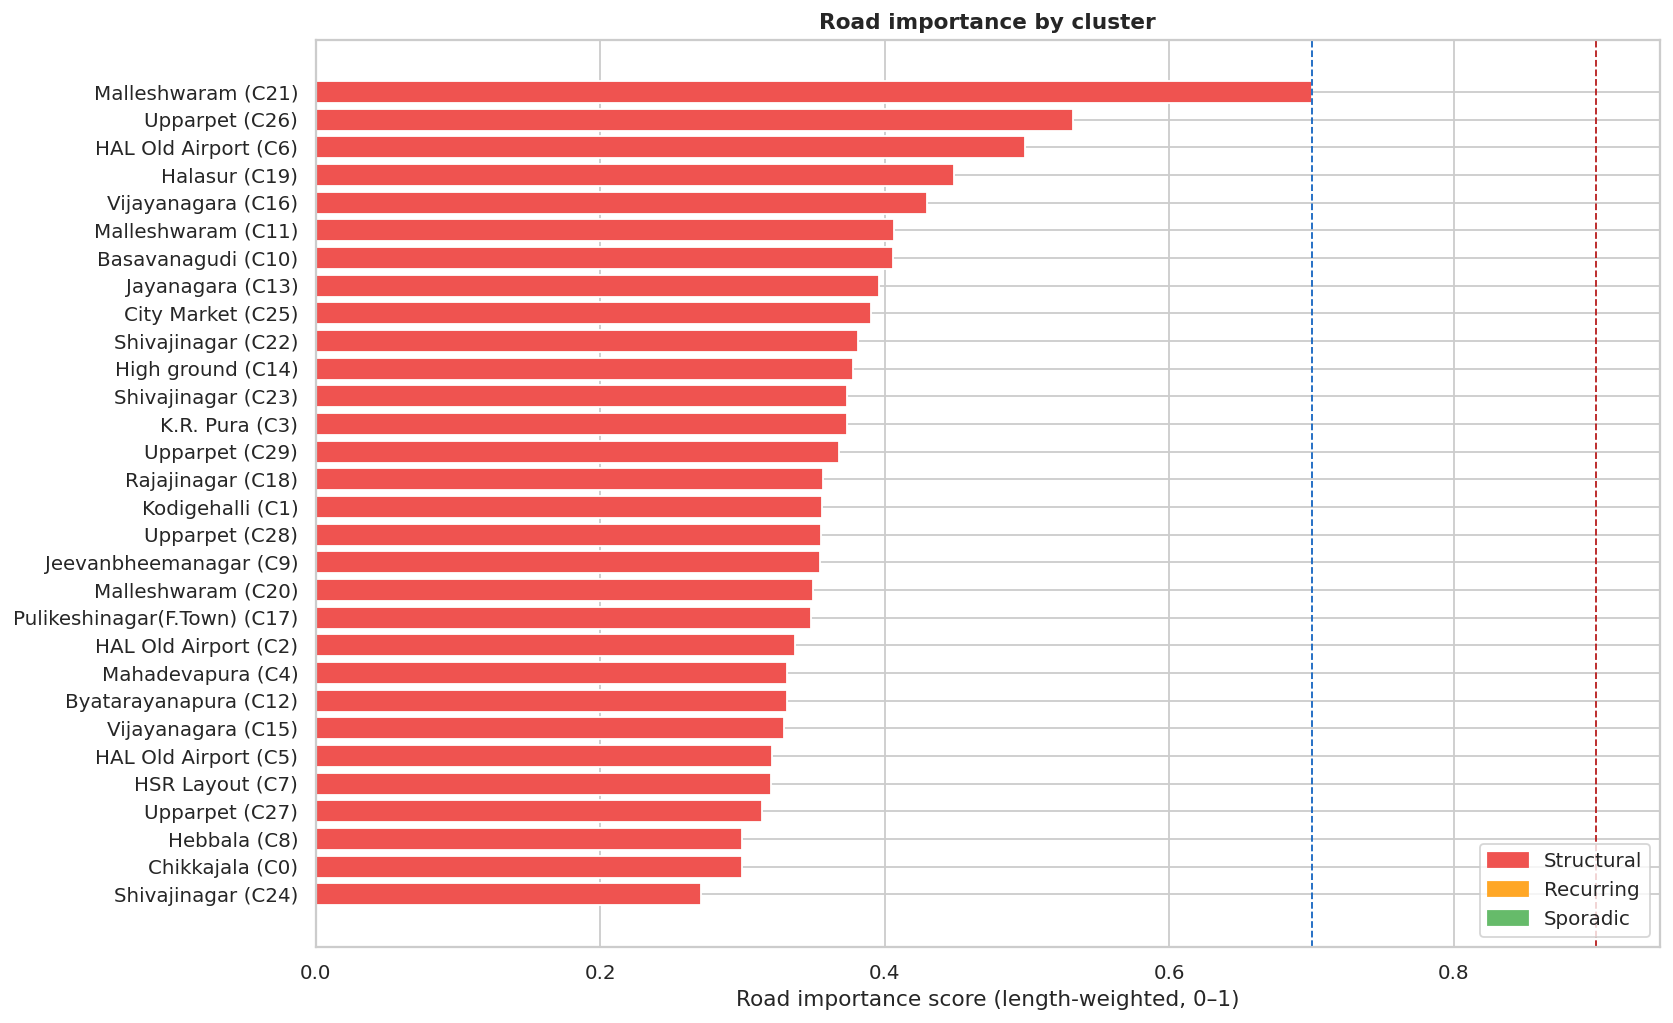


Top 10 clusters by road importance:
 cluster_id     top_station  road_importance dominant_road_type hotspot_type
         21    Malleshwaram           0.7000     secondary_link   Structural
         26        Upparpet           0.5324            primary   Structural
          6 HAL Old Airport           0.4983           tertiary   Structural
         19         Halasur           0.4486        residential   Structural
         16    Vijayanagara           0.4298        residential   Structural
         11    Malleshwaram           0.4064        residential   Structural
         10    Basavanagudi           0.4060        residential   Structural
         13      Jayanagara           0.3959        residential   Structural
         25     City Market           0.3901        residential   Structural
         22    Shivajinagar           0.3816           tertiary   Structural


In [8]:
# ── 5a. Road importance by cluster (horizontal bar) ──────────────────────────
viz = ckpt_df.merge(
    cluster_summary[["cluster_id", "top_station", "hotspot_type"]],
    on="cluster_id", how="left"
).sort_values("road_importance", ascending=True)

color_map  = {"Structural": "#EF5350", "Recurring": "#FFA726", "Sporadic": "#66BB6A"}
bar_colors = viz["hotspot_type"].map(color_map).fillna("#90A4AE")

fig, ax = plt.subplots(figsize=(13, 8))
ax.barh(
    viz["top_station"] + " (C" + viz["cluster_id"].astype(str) + ")",
    viz["road_importance"],
    color=bar_colors,
)
ax.axvline(0.7, color="#1565C0", ls="--", lw=1, label="Secondary threshold (0.7)")
ax.axvline(0.9, color="#B71C1C", ls="--", lw=1, label="Primary threshold (0.9)")
ax.set_xlabel("Road importance score (length-weighted, 0–1)")
ax.set_title("Road importance by cluster", fontweight="bold")

patches = [
    mpatches.Patch(color="#EF5350", label="Structural"),
    mpatches.Patch(color="#FFA726", label="Recurring"),
    mpatches.Patch(color="#66BB6A", label="Sporadic"),
]
ax.legend(handles=patches + ax.get_legend_handles_labels()[0][2:], loc="lower right")
plt.tight_layout()
plt.savefig(f"{BASE}/s5_road_importance.png")
plt.show()

print("\nTop 10 clusters by road importance:")
print(viz[["cluster_id", "top_station", "road_importance", "dominant_road_type", "hotspot_type"]]
      .sort_values("road_importance", ascending=False)
      .head(10)
      .to_string(index=False))

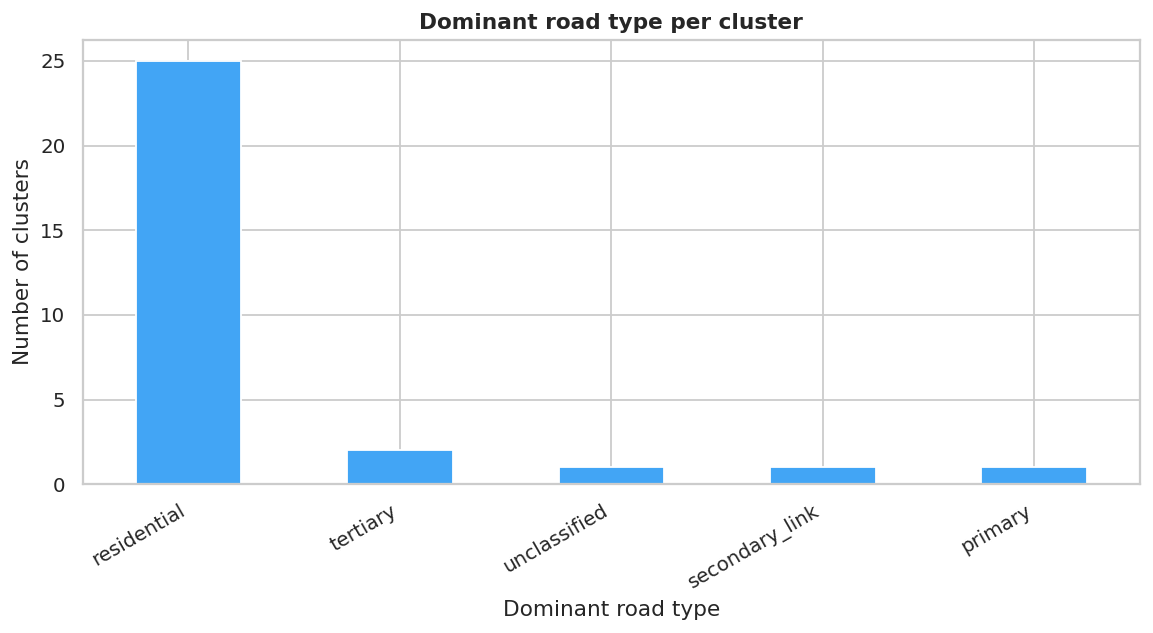

In [9]:
# ── 5b. Dominant road type distribution ──────────────────────────────────────
type_counts = (
    ckpt_df[ckpt_df["dominant_road_type"] != "imputed"]["dominant_road_type"]
    .value_counts()
)

fig, ax = plt.subplots(figsize=(9, 5))
type_counts.plot(kind="bar", ax=ax, color="#42A5F5", edgecolor="white")
ax.set_xlabel("Dominant road type")
ax.set_ylabel("Number of clusters")
ax.set_title("Dominant road type per cluster", fontweight="bold")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.savefig(f"{BASE}/s5_road_type_distribution.png")
plt.show()

## 6. Merge into `cluster_summary` and save

In [11]:
MERGE_COLS = [
    "cluster_id",
    "road_importance",
    "dominant_road_type",
    "road_count",
    "junction_count_osm",
    "query_radius_m",
    "imputed",
]

cluster_summary = cluster_summary.merge(ckpt_df[MERGE_COLS], on="cluster_id", how="left")

# Save full exposure table (all checkpoint cols including status)
ckpt_df.sort_values("cluster_id").to_csv(OUT_NET, index=False)

# Overwrite cluster_summary in place
cluster_summary.to_csv(SUM_OUT, index=False)

print("Saved:")
print(f"  road_network_exposure.csv  — {ckpt_df.shape}")
print(f"  cluster_summary.csv        — {cluster_summary.shape}")
print()
print("New columns in cluster_summary:")
new_cols = ["road_importance", "dominant_road_type", "road_count", "junction_count_osm", "imputed"]
print(cluster_summary[["cluster_id", "top_station"] + new_cols].head(10).to_string(index=False))

Saved:
  road_network_exposure.csv  — (30, 8)
  cluster_summary.csv        — (30, 53)

New columns in cluster_summary:
 cluster_id       top_station  road_importance dominant_road_type  road_count  junction_count_osm  imputed
         29          Upparpet           0.3679        residential          57                  24    False
          7        HSR Layout           0.3202        residential          58                  21    False
         25       City Market           0.3901        residential         157                  50    False
         11      Malleshwaram           0.4064        residential          71                  24    False
         27          Upparpet           0.3137        residential         477                 161    False
         20      Malleshwaram           0.3497        residential          50                  20    False
         24      Shivajinagar           0.2712       unclassified          21                   9    False
         21      Malleshw